# Buehler et al. (2019) §3.2 — Heston model variant
Replicates the same analysis as `buehler_benchmark.ipynb` but under the **Heston** stochastic-volatility model.

Two instruments: **stock** (S) and **variance swap** (VarPrice).  
Theoretical baseline: **complete-market hedge** — BS delta on the stock + variance-swap vega leg (δ_V = ∂C/∂V ÷ ∂VarSwap/∂V).  
NN hedge: `HestonHedgeNet` trained with ES_α loss using both instruments.

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.hedging.hedge_network import HestonHedgeNet
from src.hedging.theoretical import complete_market_hedge
from src.heston_simulator import HestonParams, simulate

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
RESULTS_DIR = Path('..') / 'results'

In [ ]:
# Heston parameters (match train_heston.py)
S0    = 100.0
K     = 100.0
v0    = 0.04
kappa = 1.0
theta = 0.04
xi    = 2.0
rho   = -0.7
N, dt = 30, 1/365
T     = N * dt
ALPHAS = [0.5, 0.75, 0.95, 0.99]

# Test paths (fresh seed)
params = HestonParams(
    S0=S0, v0=v0, kappa=kappa, theta=theta, xi=xi, rho=rho,
    T=T, N=N, M=100_000,
)
S_test, V_test, VP_test = simulate(params, seed=999)
print('S:        ', S_test.shape)
print('V:        ', V_test.shape)
print('VarPrice: ', VP_test.shape)

# Match the scale used during training (train_heston.py scales VarPrice by
# 1/VarPrice_0 so that ΔVarPrice ≈ O(1) and δ_V gradients are comparable
# to δ_S gradients).  The theoretical baseline uses raw VP_test (its δ_V
# is already in unscaled units), but the NN was trained on VP_scaled, so
# NN evaluation must also use VP_scaled to get the correct dollar P&L.
vp_scale    = 1.0 / float(VP_test[:, 0].mean())
VP_test_scaled = VP_test * vp_scale
print(f'VarPrice scale factor: {vp_scale:.2f}')

In [3]:
# complete_market_hedge is imported from src/hedging/theoretical.py

def compute_pl_heston(holding, S, VarPrice, p0):
    """
    P&L = p0 + Σ_t (δ_S_t ΔS_t + δ_V_t ΔVarPrice_t) − C_T
    holding: (M, N, 2) — [:,:,0] stock, [:,:,1] var-swap
    """
    dS  = S[:, 1:] - S[:, :-1]
    dVP = VarPrice[:, 1:] - VarPrice[:, :-1]
    PnL = (holding[:, :, 0] * dS + holding[:, :, 1] * dVP).sum(dim=1)
    C_T = torch.clamp(S[:, -1] - K, min=0.0)
    return p0 + PnL - C_T


def pl_stats(pl, label):
    pl = pl.numpy()
    var_levels = [0.99, 0.95, 0.90, 0.80, 0.50]
    quantiles  = [np.quantile(pl, 1 - v) for v in var_levels]
    print(f"{label:<22}  mean={pl.mean():.4f}  "
          + "  ".join(f"VaR{int(v*100)}={q:.4f}" for v, q in zip(var_levels, quantiles)))
    return pl.mean(), quantiles

In [4]:
# ---- Complete-market hedge (theoretical baseline) ----
# δ_S = N(d1) with σ = sqrt(V_t)       [stock leg]
# δ_V = (∂C/∂V) / (∂VarSwap/∂V_t)      [var-swap leg — completes the market]
# Both legs match the two-instrument setup used in the Prequel's NN training.

theory_holding = torch.zeros(S_test.shape[0], N, 2)
for t in range(N):
    tau = T - t * dt
    d_S, d_V = complete_market_hedge(S_test[:, t], V_test[:, t], tau, K, kappa)
    theory_holding[:, t, 0] = d_S
    theory_holding[:, t, 1] = d_V

# MC Heston price (risk-neutral expectation of C_T)
p0_heston = float(torch.clamp(S_test[:, -1] - K, min=0.0).mean())
print(f'MC Heston call price: {p0_heston:.4f}')

pl_theory = compute_pl_heston(theory_holding, S_test, VP_test, p0_heston)
mean_theory, q_theory = pl_stats(pl_theory, 'Heston (δ_S+δ_V)')

MC Heston call price: 1.7011
Heston (δ_S+δ_V)        mean=0.0113  VaR99=-1.5038  VaR95=-0.8687  VaR90=-0.6915  VaR80=-0.5147  VaR50=-0.1131


In [ ]:
# ---- NN hedges for each α ----
# P&L uses the MC Heston price as premium for fair comparison across models.
# VP_test_scaled must be used here because the networks were trained with
# VarPrice scaled by vp_scale; the resulting P&L is still in dollar terms.
nn_pls = {}

for alpha in ALPHAS:
    tag = str(alpha).replace('.', '')
    network = HestonHedgeNet(N=N, width=20)
    network.load_state_dict(
        torch.load(RESULTS_DIR / f'heston_ES{tag}_network.pt', weights_only=True)
    )
    network.eval()

    with torch.no_grad():
        x = torch.cat([
            torch.log(S_test[:, :-1]).unsqueeze(-1),
            V_test[:, :-1].unsqueeze(-1),
        ], dim=-1)                      # (M, N, 2)
        holding = network(x)            # (M, N, 2)

    pl = compute_pl_heston(holding, S_test, VP_test_scaled, p0_heston)
    nn_pls[alpha] = pl
    pl_stats(pl, f'ES_{alpha} NN')

In [6]:
# ---- Table 3.1 (Heston) ----
var_levels = [0.99, 0.95, 0.90, 0.80, 0.50]
header = f"{'Model':<22} {'Mean':>8}" + "".join(f"{'VaR'+str(int(v*100)):>10}" for v in var_levels)
print(header)
print('-' * len(header))

def row(label, pl):
    pl = pl.numpy()
    qs = [np.quantile(pl, 1 - v) for v in var_levels]
    return f"{label:<22} {pl.mean():>8.4f}" + "".join(f"{q:>10.4f}" for q in qs)

print(row('Heston (δ_S+δ_V)', pl_theory))
for alpha in ALPHAS:
    print(row(f'ES_{alpha} NN', nn_pls[alpha]))

Model                      Mean     VaR99     VaR95     VaR90     VaR80     VaR50
---------------------------------------------------------------------------------
Heston (δ_S+δ_V)         0.0113   -1.5038   -0.8687   -0.6915   -0.5147   -0.1131
ES_0.5 NN                0.0032   -4.7101   -2.5122   -1.6005   -0.6470    0.3187
ES_0.75 NN               0.0047   -4.1664   -2.2532   -1.4339   -0.6815    0.1638
ES_0.95 NN               0.0040   -4.1503   -2.2305   -1.4247   -0.7030    0.1510
ES_0.99 NN               0.0049   -4.1134   -2.2137   -1.4278   -0.7057    0.1500


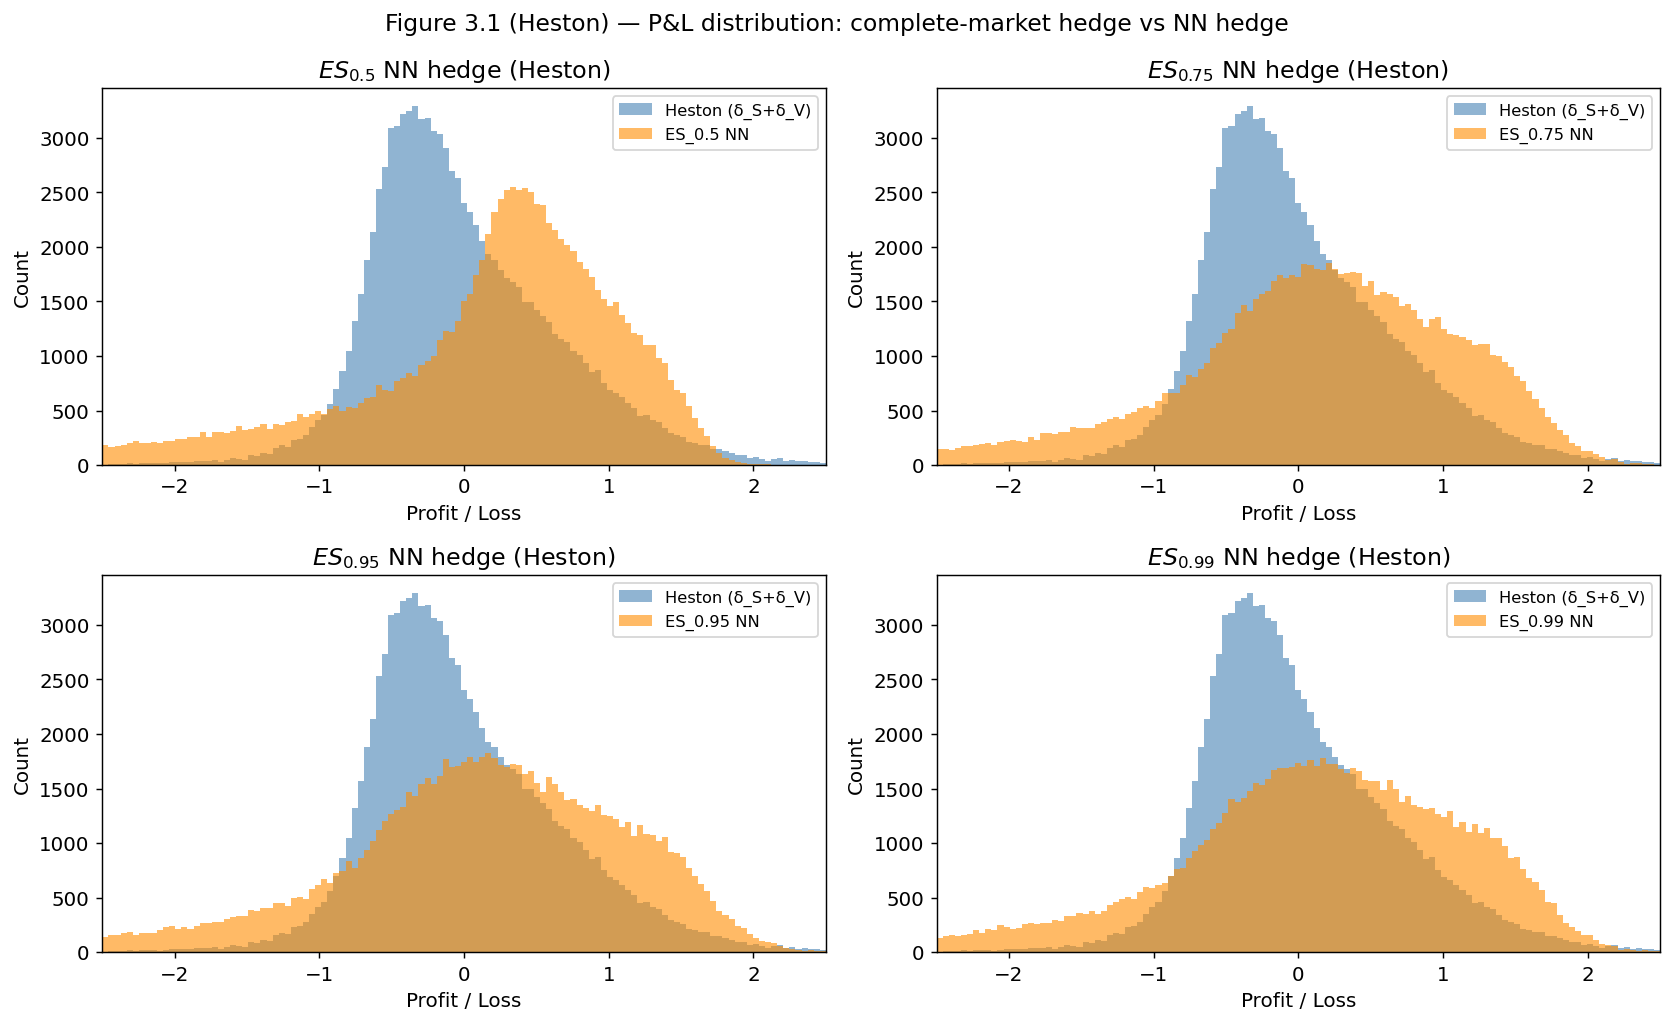

In [7]:
# ---- Figure 3.1 (Heston) ----
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, alpha in zip(axes.flat, ALPHAS):
    pl_nn   = nn_pls[alpha].numpy()
    pl_base = pl_theory.numpy()
    xlim = (-2.5, 2.5)
    bins = np.linspace(*xlim, 120)

    ax.hist(pl_base, bins=bins, alpha=0.6, color='steelblue',
            label='Heston (δ_S+δ_V)', density=False)
    ax.hist(pl_nn,   bins=bins, alpha=0.6, color='darkorange',
            label=f'ES_{alpha} NN', density=False)
    ax.set_xlim(xlim)
    ax.set_xlabel('Profit / Loss')
    ax.set_ylabel('Count')
    ax.set_title(f'$ES_{{{alpha}}}$ NN hedge (Heston)')
    ax.legend(fontsize=9)

fig.suptitle('Figure 3.1 (Heston) — P&L distribution: complete-market hedge vs NN hedge', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'heston_figure31.png', bbox_inches='tight')
plt.show()

## Figure 6 & 7 (Heston)
Compare **50%-CVaR** vs **99%-CVaR** strategies.

* **Figure 6**: raw loss distribution `−P&L = C_T − PnL − p0_heston`.
* **Figure 7**: normalised by `p0_heston` + summary table.

Unlike GBM (complete market), Heston has unhedgeable vol-of-vol risk — the NN with variance swap should
outperform the local-vol delta, and the CVaR trade-off between α=0.5 and α=0.99 is more pronounced.

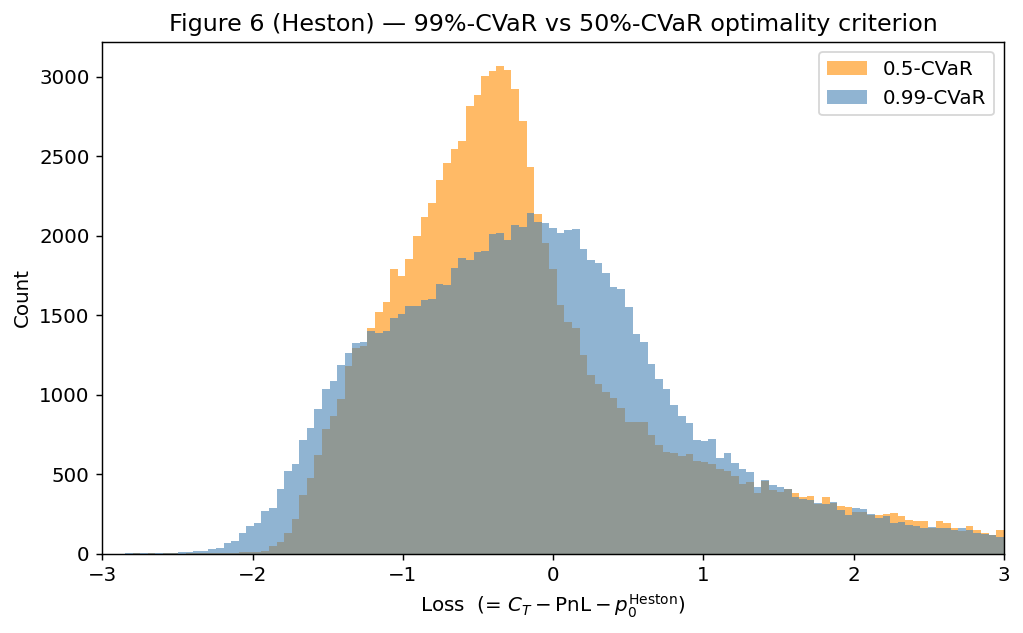

In [8]:
# ---- Figure 6 (Heston): raw loss distribution ----
loss_50 = -nn_pls[0.5].numpy()
loss_99 = -nn_pls[0.99].numpy()

xlim = (-3.0, 3.0)
bins = np.linspace(*xlim, 120)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(loss_50, bins=bins, alpha=0.6, color='darkorange', label='0.5-CVaR')
ax.hist(loss_99, bins=bins, alpha=0.6, color='steelblue',  label='0.99-CVaR')
ax.set_xlim(xlim)
ax.set_xlabel('Loss  (= $C_T - \\mathrm{PnL} - p_0^{\\mathrm{Heston}}$)')
ax.set_ylabel('Count')
ax.set_title('Figure 6 (Heston) — 99%-CVaR vs 50%-CVaR optimality criterion')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'heston_figure6.png', bbox_inches='tight')
plt.show()

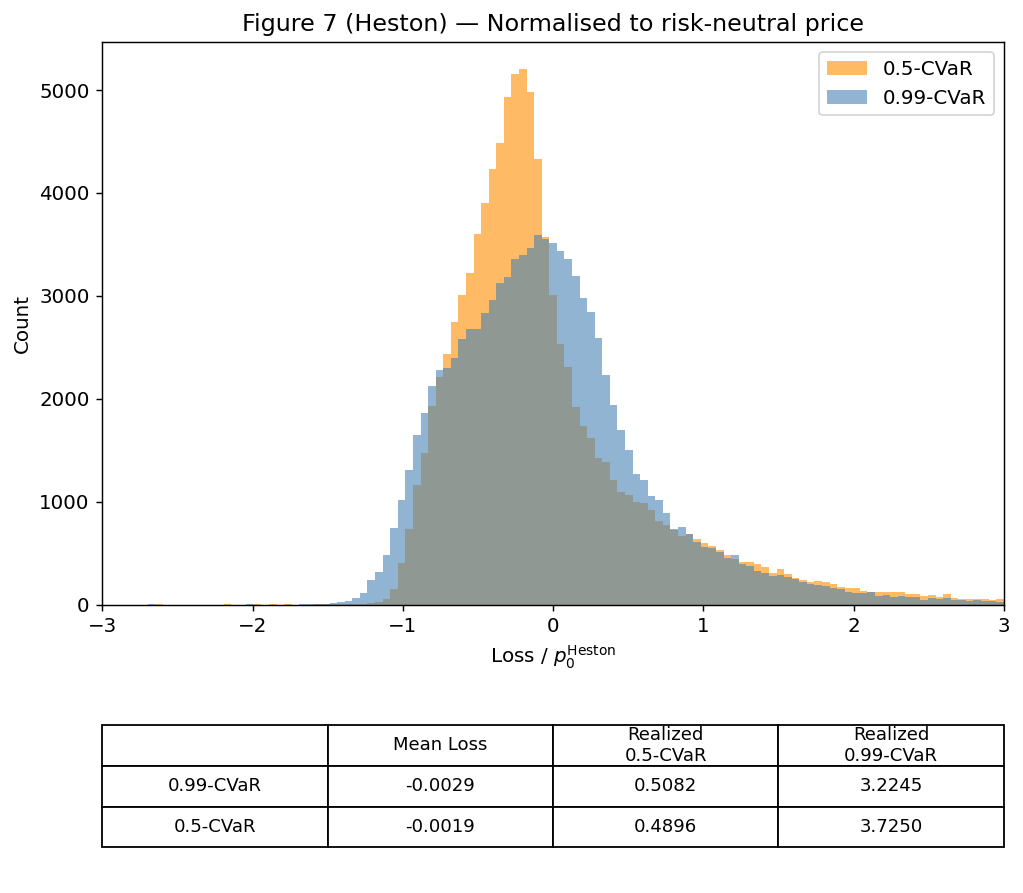

               Mean Loss   Real.0.5-CVaR   Real.0.99-CVaR
----------------------------------------------------------
    0.5-CVaR     -0.0019          0.4896           3.7250
   0.99-CVaR     -0.0029          0.5082           3.2245


In [9]:
# ---- Figure 7 (Heston): normalised loss + summary table ----
def realized_cvar(loss_arr, alpha):
    """ES_α = E[loss | loss > VaR_α(loss)]."""
    var  = np.quantile(loss_arr, alpha)
    tail = loss_arr[loss_arr > var]
    return tail.mean() if len(tail) > 0 else var

norm_loss_50 = loss_50 / p0_heston
norm_loss_99 = loss_99 / p0_heston

xlim_n = (-3.0, 3.0)
bins_n = np.linspace(*xlim_n, 120)

fig, (ax_hist, ax_table) = plt.subplots(
    2, 1, figsize=(8, 7),
    gridspec_kw={'height_ratios': [3, 1]},
)

ax_hist.hist(norm_loss_50, bins=bins_n, alpha=0.6, color='darkorange', label='0.5-CVaR')
ax_hist.hist(norm_loss_99, bins=bins_n, alpha=0.6, color='steelblue',  label='0.99-CVaR')
ax_hist.set_xlim(xlim_n)
ax_hist.set_xlabel('Loss / $p_0^{\\mathrm{Heston}}$')
ax_hist.set_ylabel('Count')
ax_hist.set_title('Figure 7 (Heston) — Normalised to risk-neutral price')
ax_hist.legend()

rows   = ['0.99-CVaR', '0.5-CVaR']
losses = [norm_loss_99, norm_loss_50]
col_labels = ['', 'Mean Loss', 'Realized\n0.5-CVaR', 'Realized\n0.99-CVaR']
table_data = [
    [rows[i],
     f'{losses[i].mean():.4f}',
     f'{realized_cvar(losses[i], 0.5):.4f}',
     f'{realized_cvar(losses[i], 0.99):.4f}']
    for i in range(2)
]

ax_table.axis('off')
tbl = ax_table.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'heston_figure7.png', bbox_inches='tight')
plt.show()

# Print table
print(f"{'':>12}  {'Mean Loss':>10}  {'Real.0.5-CVaR':>14}  {'Real.0.99-CVaR':>15}")
print('-' * 58)
for label, arr in [('0.5-CVaR', norm_loss_50), ('0.99-CVaR', norm_loss_99)]:
    print(f"{label:>12}  {arr.mean():>10.4f}  {realized_cvar(arr, 0.5):>14.4f}  {realized_cvar(arr, 0.99):>15.4f}")